In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\acer\Downloads\titanic\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
df.info()
df.describe()
(df.isnull().sum()/len(df))*100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [5]:
pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100
# import seaborn as sns
# import matplotlib.pyplot as plt
# sns.heatmap(ab,annot=True)
# plt.show

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


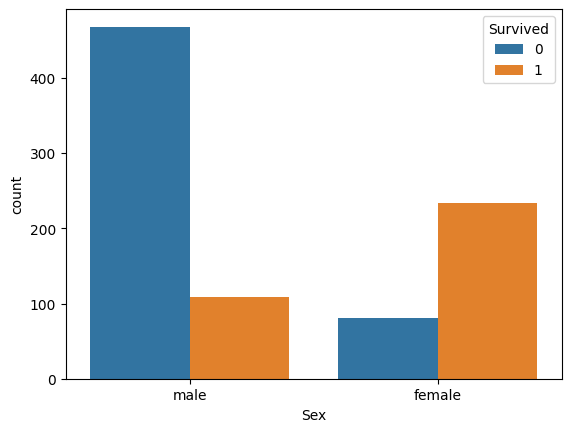

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.show()

In [7]:
df.drop("Cabin", axis=1, inplace= True)

In [8]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [9]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [10]:
df.shape

(891, 11)

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [12]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.45,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q


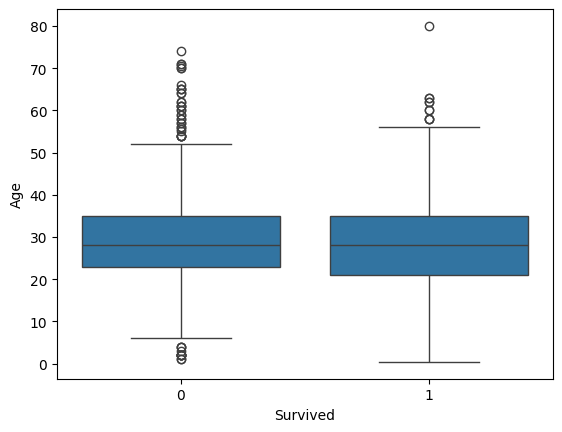

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="Survived",
    y="Age",
    data=df
)

plt.show()

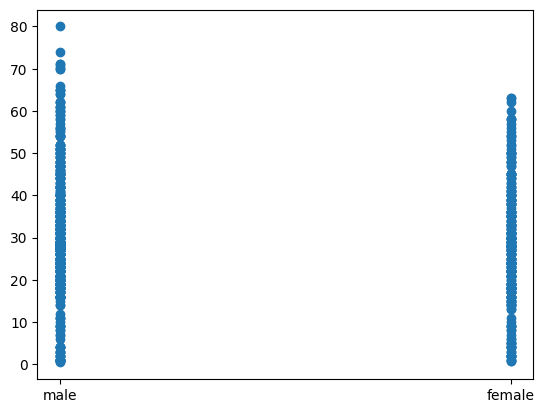

In [14]:
import matplotlib.pyplot as plt
plt.scatter(df["Sex"], df["Age"])
plt.show()


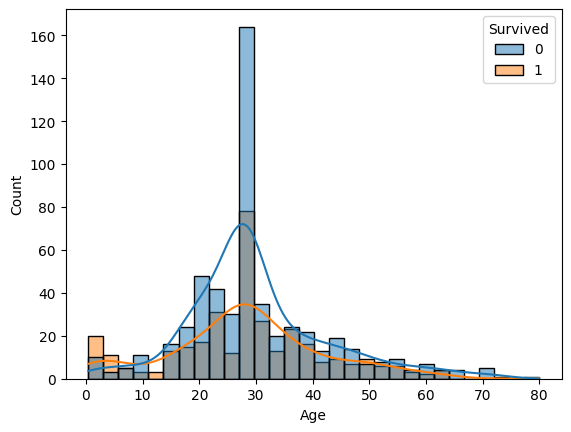

In [15]:
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    kde=True
)

plt.show()

In [16]:
df["AgeGroup"]=pd.cut(
    df["Age"],
       bins=[0,12,18,35,60,100],
    labels=[
        "Child",
        "Teen",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

pd.crosstab(
    df["AgeGroup"],
    df["Survived"],
    normalize="index"
)*100

Survived,0,1
AgeGroup,,
Child,42.028986,57.971014
Teen,57.142857,42.857143
Young Adult,64.672897,35.327103
Adult,60.000000,40.000000
Senior,77.272727,22.727273


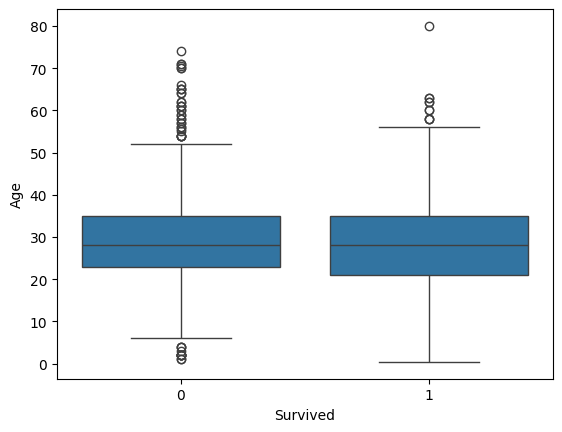

In [17]:
# df.groupby("Survived")["Age"].mean()
import seaborn as sns
sns.boxplot(
    x="Survived",
    y="Age",
    data=df
)

plt.show()


In [18]:
df.groupby("Survived")["Age"].mean()

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

In [19]:
pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
)*100


Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


In [20]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

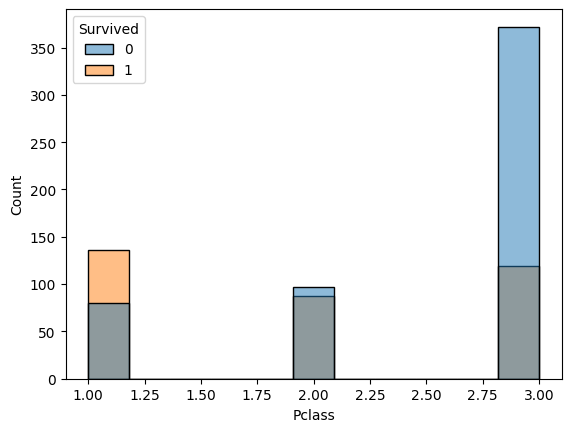

In [22]:
sns.histplot(
    data=df,
    x="Pclass",
    hue="Survived",
)

plt.show()

In [23]:

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Young Adult


In [24]:
df.groupby("Survived")["Fare"].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

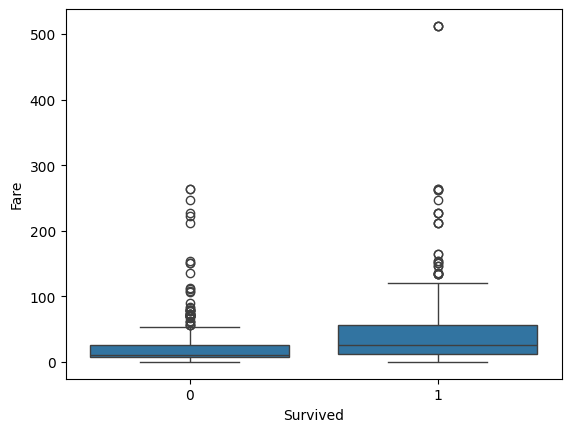

In [25]:
sns.boxplot(
    x="Survived",
    y="Fare",
    data=df
)
plt.show()

In [28]:
df[df["Fare"]>50]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Young Adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,Adult
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S,Young Adult
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,28.0,1,0,PC 17569,146.5208,C,Young Adult
...,...,...,...,...,...,...,...,...,...,...,...,...
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,S,Adult
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,28.0,8,2,CA. 2343,69.5500,S,Young Adult
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,S,Young Adult
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,S,Adult


In [29]:
pd.crosstab(
    df["Embarked"],
    df["Survived"],
)

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


<Axes: xlabel='Survived', ylabel='count'>

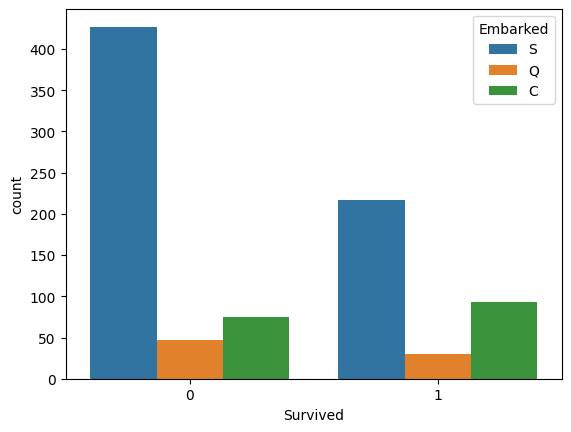

In [32]:
sns.countplot(x="Survived", hue="Embarked", data= df)

In [35]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Young Adult


In [36]:
df["FamilyCount"]=(df["SibSp"]+df["Parch"]+1)

In [37]:
df["FamilyCount"].head()

0    2
1    2
2    1
3    2
4    1
Name: FamilyCount, dtype: int64

In [41]:
df[["FamilyCount", "Survived"]]

,FamilyCount,Survived
0,2,0
1,2,1
2,1,1
3,2,1
4,1,0
...,...,...
886,1,0
887,1,1
888,4,0
889,1,1


In [43]:
df.groupby("FamilyCount")["Survived"].mean()

FamilyCount
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [44]:
df["Title"]=df["Name"].str.extract(r'([A-Za-z]+)\.')

In [46]:
df["Title"]

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: object

In [47]:
df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [50]:
pd.crosstab(
    df["Title"],
    df["Survived"],
    normalize="index")*100

Survived,0,1
Title,,
Capt,100.000000,0.000000
Col,50.000000,50.000000
Countess,0.000000,100.000000
Don,100.000000,0.000000
Dr,57.142857,42.857143
Jonkheer,100.000000,0.000000
Lady,0.000000,100.000000
Major,50.000000,50.000000
Master,42.500000,57.500000
